In [10]:
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from parking_env import ParkingEnv

print("Imports done")

Imports done


In [11]:
env = ParkingEnv()

obs, info = env.reset()

print("Start State:", obs)
print("Environment ready")

Start State: [1. 1. 2. 8. 7.]
Environment ready


In [12]:
model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.001,
    buffer_size=50000,
    learning_starts=1000,
    batch_size=32,
    gamma=0.95
)


model.learn(total_timesteps=10000)

print("Training completed")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------------
| rollout/            |           |
|    ep_len_mean      | 107       |
|    ep_rew_mean      | -1.07e+03 |
|    exploration_rate | 0.593     |
| time/               |           |
|    episodes         | 4         |
|    fps              | 3786      |
|    time_elapsed     | 0         |
|    total_timesteps  | 428       |
-----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 111      |
|    ep_rew_mean      | -693     |
|    exploration_rate | 0.155    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4355     |
|    time_elapsed     | 0        |
|    total_timesteps  | 890      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 120      |
|    ep_rew_mean    

In [13]:
model.save("parking_dqn")

print("Model saved")

Model saved


In [17]:
model = DQN.load("parking_dqn")

obs, info = env.reset()

done = False

path = []


while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = env.step(action)

    # store car movement
    path.append(
        (env.car_x, env.car_y)
    )

    done = terminated or truncated


print("Steps:", len(path))
print("Final Position:", path[-1])

Steps: 200
Final Position: (np.int64(0), np.int64(8))


In [26]:
print("Target:", (env.target_x, env.target_y))
print("Final:", path[-1])

if path[-1] == (env.target_x, env.target_y):
    print("SUCCESS 🚗🎯")
else:
    print("TIMEOUT / FAILED ")

Target: (9, 7)
Final: (9, 7)
SUCCESS 🚗🎯


In [27]:
successful = False

attempt = 0

while not successful and attempt < 100:

    obs, info = env.reset()

    path = []

    done = False

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, terminated, truncated, info = env.step(action)

        path.append(
            (int(env.car_x), int(env.car_y))
        )

        done = terminated or truncated


    attempt += 1


    if path[-1] == (env.target_x, env.target_y):
        successful = True
        print("SUCCESS FOUND 🚗🎯")
        print("Attempt:", attempt)
        print("Steps:", len(path))


if not successful:
    print("No successful run found after 100 attempts")

SUCCESS FOUND 🚗🎯
Attempt: 4
Steps: 17


In [28]:
import os

for file in os.listdir():
    if file.endswith(".zip"):
        print(file)

parking_dqn.zip
parking_dqn_best.zip


In [21]:
from stable_baselines3 import DQN
from parking_env import ParkingEnv


env = ParkingEnv()


model = DQN(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=0.0005,
    buffer_size=100000,
    learning_starts=5000,
    batch_size=64,
    gamma=0.99,
    exploration_fraction=0.3,
    exploration_final_eps=0.05
)


model.learn(
    total_timesteps=50000
)


model.save("parking_dqn_best")


print("Training finished and model saved 🚗")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 169      |
|    ep_rew_mean      | 114      |
|    exploration_rate | 0.957    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 3919     |
|    time_elapsed     | 0        |
|    total_timesteps  | 677      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 160      |
|    ep_rew_mean      | -255     |
|    exploration_rate | 0.919    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 4331     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1283     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 140      |
|    ep_rew_mean      | -437   

In [29]:
model = DQN.load("parking_dqn_best")

successful = False
attempt = 0

while not successful and attempt < 100:

    obs, info = env.reset()

    path = []
    done = False

    while not done:

        action, _ = model.predict(
            obs,
            deterministic=True
        )

        obs, reward, terminated, truncated, info = env.step(action)

        path.append(
            (int(env.car_x), int(env.car_y))
        )

        done = terminated or truncated


    attempt += 1

    if path[-1] == (env.target_x, env.target_y):
        successful = True
        print("SUCCESS")
        print("Steps:", len(path))


if not successful:
    print("Still failed")

SUCCESS
Steps: 21


In [30]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(6,6))


def update(frame):

    ax.clear()

    # grid
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)

    ax.set_xticks(range(10))
    ax.set_yticks(range(10))

    ax.grid(True)


    # obstacles
    for obstacle in env.obstacles:

        ax.scatter(
            obstacle[1],
            obstacle[0],
            marker="s",
            s=700
        )


    # target
    ax.scatter(
        env.target_y,
        env.target_x,
        marker="*",
        s=900
    )


    # car
    car = path[frame]

    ax.scatter(
        car[1],
        car[0],
        marker="o",
        s=600
    )


    ax.set_title(
        f"Autonomous Car Parking \nStep {frame}"
    )


ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(path),
    interval=500
)


ani.save(
    "parking_agent_demo.gif",
    writer="pillow"
)


plt.close()


print("GIF created successfully")

GIF created successfully


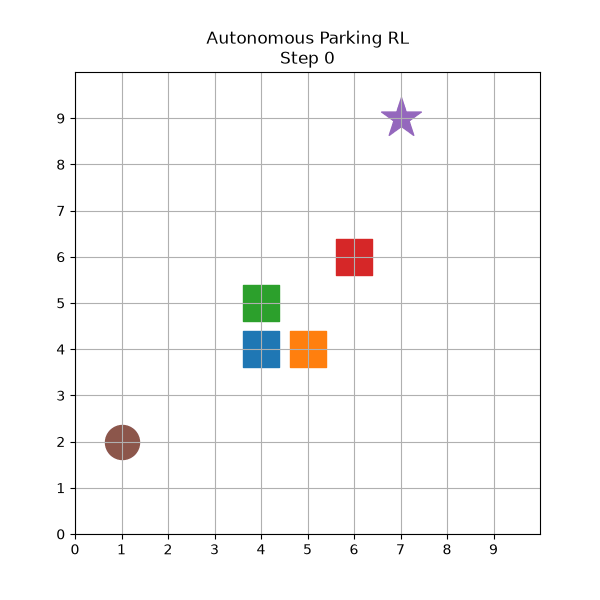

In [25]:
from IPython.display import Image, display

display(Image(filename="parking_agent_demo.gif"))